# TPC-C Collector Demo

# Missing
* connection data beyond loading
* join to connection data
* join to monitoring_single
* connection and configuration also in monitoring and connection df

## Naming
* There is an experiment having a code, say `1775855486`.
* The experiment inspects a SUT, say `PostgreSQL-A`. This is called a `configuration`.
* The experiment is run several times, say twice. The indicator of the run is called `experiment_run`.
* Each run can have several phases as a sequence. The number of the phase is called `client`. The state of the configuration in a phase is called a `connection`.
* Each client can have several `pods`, that are run in parallel. A pod represents a driver.
* Performance metrics are collected per driver pod.  
    The naming of an instance is `<sut>-<experiment_run>-<client>-<pod>`. It is unique per experiment.
* Monitoring metrics are collected per phase. They are automatically aggregated across parallel pods.  
    The naming of an instance is `<sut>-<experiment_run>-<client>`. It is unique per experiment.

## Aggregation
* Aggregation is complicated. Some metrics are aggregated via count, sum, max or average. Others cannot be aggregated sensibly, like experiment code or latency percentiles.
* There are helper functions to aggregated pods that are certainly run in parallel.  
  So `<sut>-<experiment_run>-<client>-<pod>` are aggregated to `<sut>-<experiment_run>-<client>`.
* An exception is multi-tenancy.

## Class `collector`
* constructor `collectors.benchbase(path, codes)`
* evaluator object `evaluate = collect.get_evaluator()`
* dataframe of connection infos `collect.get_connections()`
  * index is name of client
* **monitoring metrics**
  * dataframe of available metrics `collect.df_metrics`
    * index is key of metric
  * dataframe of monitored components `collect.get_monitored_phases()`
    * index is key of component
  * dataframe of aggregated metrics per connection `collect.get_monitoring_single_all()`
    * index is name of client
    * metrics aggregated per code, experiment_run and client
  * dataframe of aggregated metrics per connection and across tenants `collect.get_monitoring_all()`
    * index just enumerates
    * metrics aggregated per code, experiment_run and client and across tenants
  * dataframe of time series for a metric of a connection in an experiment `collect.get_monitoring_timeseries_single(code, metric)`
    * index is name of connection
    * unstacked (wide format)
  * dataframe of time series for a metric in all experiments `collect.get_monitoring_timeseries_all(metric)`
    * index just enumerates
    * stacked (long format)
* **performance metrics**
  * dataframe of loading metrics `collect.get_loading_time_max_all()`
    * index is name of client
  * dataframe of performance aggregated per parallel client `collect.get_performance_all()`
    * index just enumerates
    * performance aggregated per code, experiment_run and client
  * dataframe of performance for one experiment `collect.get_performance_single()`
    * performance of each single client (driver)
    * index is name of client pod
  * dataframe of performance for all experiments `collect.get_performance_all_single()`
    * performance of each single client (driver)
    * index is name of client pod


[1] [Benchmarking Multi-Tenant Architectures in PostgreSQL](https://doi.org/10.48786/edbt.2026.46)
> Erdelt, P.K., and Rabl T. (2026)
> In: Proceedings 29th International Conference on Extending Database Technology, EDBT 2026
> OpenProceedings.org
> https://doi.org/10.48786/edbt.2026.46


In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = '{:.2f}'.format

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
from notebookutils import *

# Collect Results

In [3]:
#path = r"D:\data\benchmarks"
path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [4]:
codes = [
    "1776068373",
    "1776070965"
]

codes

['1776068373', '1776070965']

In [5]:
collect = collectors.benchbase(path, codes)

# Get all Metrics Metadata

## Metrics Names and Types

Metrics that are derived from monitoring

In [6]:
collect.df_metrics

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


## Names of Monitored Phases

Names of components and their phases

In [7]:
collect.get_monitored_phases()

,description
loading,Loading phase: SUT deployment
loader,Loading phase: component loader
stream,Execution phase: SUT deployment
benchmarker,Execution phase: component benchmarker


# Get Connection Infos

List of states of SUTs, containing loading infos.

In [8]:
df=collect.get_connections()

In [9]:
df.T

,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
code,1776068373,1776068373,1776068373,1776068373,1776070965,1776070965,1776070965,1776070965
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
dockerimage,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
time_load,1167.00,1167.00,1167.00,1167.00,1168.00,1168.00,1168.00,1168.00
time_ingest,540.00,540.00,540.00,540.00,539.00,539.00,539.00,539.00
time_check,627.00,627.00,627.00,627.00,629.00,629.00,629.00,629.00
terminals,1,1,1,1,1,1,1,1
pods,1,2,1,2,4,8,4,8


# Monitoring Aggregated per Connection

In [10]:
df_performance = collect.get_monitoring_aggregated_per_connection("stream")
df_performance.T

,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],8628.88,8869.30,7874.41,8229.47,8735.25,9001.52,8021.33,8438.03
Memory Usage Cached [MiB],10394.14,10818.59,10288.36,10854.52,10522.31,10996.87,10449.87,11135.28
CPU Utilization,2.13,2.25,1.69,2.21,2.32,2.13,1.89,2.06
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],680.77,737.86,2294.15,802.87,745.38,599.13,2394.02,738.78
CPU User Time [s],379.73,404.41,1492.76,456.00,421.24,335.71,1574.12,411.34
CPU System Time [s],301.05,333.45,801.39,346.87,324.14,263.42,819.90,327.44
Network Rx Total [MiB],944.70,759.01,3538.23,630.25,1002.77,473.14,2890.70,600.89
Network Tx Total [MiB],1685.03,852.50,1880.37,744.43,1655.01,564.09,1399.42,609.21


### With Metadata

In [11]:
df_performance = collect.add_metadata(df_performance)
df_performance.T

combine on index


,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],8628.88,8869.30,7874.41,8229.47,8735.25,9001.52,8021.33,8438.03
Memory Usage Cached [MiB],10394.14,10818.59,10288.36,10854.52,10522.31,10996.87,10449.87,11135.28
CPU Utilization,2.13,2.25,1.69,2.21,2.32,2.13,1.89,2.06
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],680.77,737.86,2294.15,802.87,745.38,599.13,2394.02,738.78
CPU User Time [s],379.73,404.41,1492.76,456.00,421.24,335.71,1574.12,411.34
CPU System Time [s],301.05,333.45,801.39,346.87,324.14,263.42,819.90,327.44
Network Rx Total [MiB],944.70,759.01,3538.23,630.25,1002.77,473.14,2890.70,600.89
Network Tx Total [MiB],1685.03,852.50,1880.37,744.43,1655.01,564.09,1399.42,609.21


# Time Series of a Single Metric for a Single Experiment

In [12]:
metric = 'total_cpu_memory'
code = codes[0]
df = collect.get_monitoring_timeseries_per_connection(code, metric=metric)
df.T

,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2
0,7528.44,7740.96,7928.73,7079.21
1,7528.44,7740.96,7928.73,7079.21
2,7528.44,7740.96,7928.73,7079.21
3,7528.44,7740.96,7928.73,7079.21
4,7528.44,7740.96,7928.73,7079.21
5,7528.44,7740.96,7928.73,7079.21
6,7528.44,7740.96,7928.73,7079.21
7,7528.44,7740.96,7928.73,7079.21
8,7528.44,7740.96,7928.73,7079.21
9,7528.44,7740.96,7928.73,7079.21


### With Metadata

In [13]:
df_performance = collect.add_metadata(df)
df_performance.T

combine on index


,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
0,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
1,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
2,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
3,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
4,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
5,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
6,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
7,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
8,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN
9,7528.44,7740.96,7928.73,7079.21,NaN,NaN,NaN,NaN


# Time Series of a Single Metric for All Experiments

In [40]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_all(metric=metric)

,timestamp,code,experiment_run,client,type,vol_tenants,num_tenants,value
0,0,1776068373,1,1,None,False,0,7528.44
1,0,1776068373,1,2,None,False,0,7740.96
2,0,1776068373,2,1,None,False,0,7928.73
3,0,1776068373,2,2,None,False,0,7079.21
4,1,1776068373,1,1,None,False,0,7528.44
5,1,1776068373,1,2,None,False,0,7740.96
6,1,1776068373,2,1,None,False,0,7928.73
7,1,1776068373,2,2,None,False,0,7079.21
8,2,1776068373,1,1,None,False,0,7528.44
9,2,1776068373,1,2,None,False,0,7740.96


# Performance Results per Pod

In [15]:
df_performance = collect.get_performance_per_pod()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

connection_pod,1776070965-PostgreSQL-1-1-1024-1-1-1,1776070965-PostgreSQL-1-1-1024-1-2-1,1776070965-PostgreSQL-1-1-1024-1-2-2,1776070965-PostgreSQL-1-1-1024-2-1-1,1776070965-PostgreSQL-1-1-1024-2-2-1,1776070965-PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-1-2,PostgreSQL-1-1-1024-1-1-3,PostgreSQL-1-1-1024-1-1-4,...,PostgreSQL-1-1-1024-2-1-3,PostgreSQL-1-1-1024-2-1-4,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-2-2-3,PostgreSQL-1-1-1024-2-2-4,PostgreSQL-1-1-1024-2-2-5,PostgreSQL-1-1-1024-2-2-6,PostgreSQL-1-1-1024-2-2-7,PostgreSQL-1-1-1024-2-2-8
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,...,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,...,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,1,2,2,2,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
code,1776068373,1776068373,1776068373,1776068373,1776068373,1776068373,1776070965,1776070965,1776070965,1776070965,...,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965
client,1,2,2,1,2,2,1,1,1,1,...,1,1,2,2,2,2,2,2,2,2
pod,kbln7.dbmsbenchmarker,59c99.dbmsbenchmarker,9g88r.dbmsbenchmarker,f4nnm.dbmsbenchmarker,5srx2.dbmsbenchmarker,nrb8j.dbmsbenchmarker,bqrrx.dbmsbenchmarker,mtfvp.dbmsbenchmarker,p6q8b.dbmsbenchmarker,rhjx2.dbmsbenchmarker,...,lqgl9.dbmsbenchmarker,rbhh2.dbmsbenchmarker,jb7jc.dbmsbenchmarker,gb2xp.dbmsbenchmarker,nptv6.dbmsbenchmarker,7bmt2.dbmsbenchmarker,9zcnd.dbmsbenchmarker,v765j.dbmsbenchmarker,8vcjs.dbmsbenchmarker,chh6b.dbmsbenchmarker
pod_count,1,2,2,1,2,2,4,4,4,4,...,4,4,8,8,8,8,8,8,8,8
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,...,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,...,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,8192,8192,16384,8192,8192,5120,5120,5120,5120,...,5120,5120,2560,2560,2560,2560,2560,2560,2560,2560


### Add Metadata

In [16]:
df = collect.add_metadata(df_performance)
df.T

combine on columns


connection_pod,1776070965-PostgreSQL-1-1-1024-1-1-1,1776070965-PostgreSQL-1-1-1024-1-2-1,1776070965-PostgreSQL-1-1-1024-1-2-2,1776070965-PostgreSQL-1-1-1024-2-1-1,1776070965-PostgreSQL-1-1-1024-2-2-1,1776070965-PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-1-2,PostgreSQL-1-1-1024-1-1-3,PostgreSQL-1-1-1024-1-1-4,...,PostgreSQL-1-1-1024-2-1-3,PostgreSQL-1-1-1024-2-1-4,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-2-2-3,PostgreSQL-1-1-1024-2-2-4,PostgreSQL-1-1-1024-2-2-5,PostgreSQL-1-1-1024-2-2-6,PostgreSQL-1-1-1024-2-2-7,PostgreSQL-1-1-1024-2-2-8
code,1776068373,1776068373,1776068373,1776068373,1776068373,1776068373,1776070965,1776070965,1776070965,1776070965,...,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965,1776070965
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,...,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,...,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,1,2,2,2,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
client,1,2,2,1,2,2,1,1,1,1,...,1,1,2,2,2,2,2,2,2,2
pod,kbln7.dbmsbenchmarker,59c99.dbmsbenchmarker,9g88r.dbmsbenchmarker,f4nnm.dbmsbenchmarker,5srx2.dbmsbenchmarker,nrb8j.dbmsbenchmarker,bqrrx.dbmsbenchmarker,mtfvp.dbmsbenchmarker,p6q8b.dbmsbenchmarker,rhjx2.dbmsbenchmarker,...,lqgl9.dbmsbenchmarker,rbhh2.dbmsbenchmarker,jb7jc.dbmsbenchmarker,gb2xp.dbmsbenchmarker,nptv6.dbmsbenchmarker,7bmt2.dbmsbenchmarker,9zcnd.dbmsbenchmarker,v765j.dbmsbenchmarker,8vcjs.dbmsbenchmarker,chh6b.dbmsbenchmarker
pod_count,1,2,2,1,2,2,4,4,4,4,...,4,4,8,8,8,8,8,8,8,8
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,...,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,...,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,8192,8192,16384,8192,8192,5120,5120,5120,5120,...,5120,5120,2560,2560,2560,2560,2560,2560,2560,2560


# Performance Results per Total

In [17]:
df_performance = collect.get_performance_aggregated_per_connection()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)

In [18]:
df_performance.T

,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
code,1776068373,1776068373,1776068373,1776068373,1776070965,1776070965,1776070965,1776070965
pod_count,1,2,1,2,4,8,4,8
duration,307,306,305,304,305,308,308,310
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,16384,16384,16384,20480,20480,20480,20480


### With Metadata

In [19]:
df = collect.add_metadata(df_performance)
df.T

combine on columns


connection_pod,1776068373-PostgreSQL-1-1-1024-1-1,1776068373-PostgreSQL-1-1-1024-1-2,1776068373-PostgreSQL-1-1-1024-2-1,1776068373-PostgreSQL-1-1-1024-2-2,1776070965-PostgreSQL-1-1-1024-1-1,1776070965-PostgreSQL-1-1-1024-1-2,1776070965-PostgreSQL-1-1-1024-2-1,1776070965-PostgreSQL-1-1-1024-2-2
code,1776068373,1776068373,1776068373,1776068373,1776070965,1776070965,1776070965,1776070965
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
pod_count,1,2,1,2,4,8,4,8
duration,307,306,305,304,305,308,308,310
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,16384,16384,16384,20480,20480,20480,20480


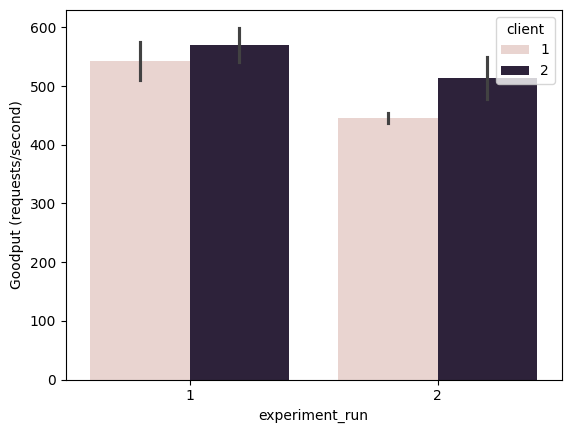

In [20]:
import seaborn as sns

sns.barplot(data=df_performance, x='experiment_run', y='Goodput (requests/second)', hue='client')
plt.show()


# Performance at Ingestion

In [21]:
df_performance = collect.get_loading_time_max_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
time_load,1167.00,1167.00,1167.00,1167.00,1168.00,1168.00,1168.00,1168.00
time_ingest,540.00,540.00,540.00,540.00,539.00,539.00,539.00,539.00
time_check,627.00,627.00,627.00,627.00,629.00,629.00,629.00,629.00
terminals,1,1,1,1,1,1,1,1
pods,1,2,1,2,4,8,4,8
tenant,,,,,,,,
client,1,2,1,2,1,2,1,2
num_worker,0,0,0,0,0,0,0,0
datadisk,4307,4518,4704,4837,4307,4555,4762,4900
type,None,None,None,None,None,None,None,None


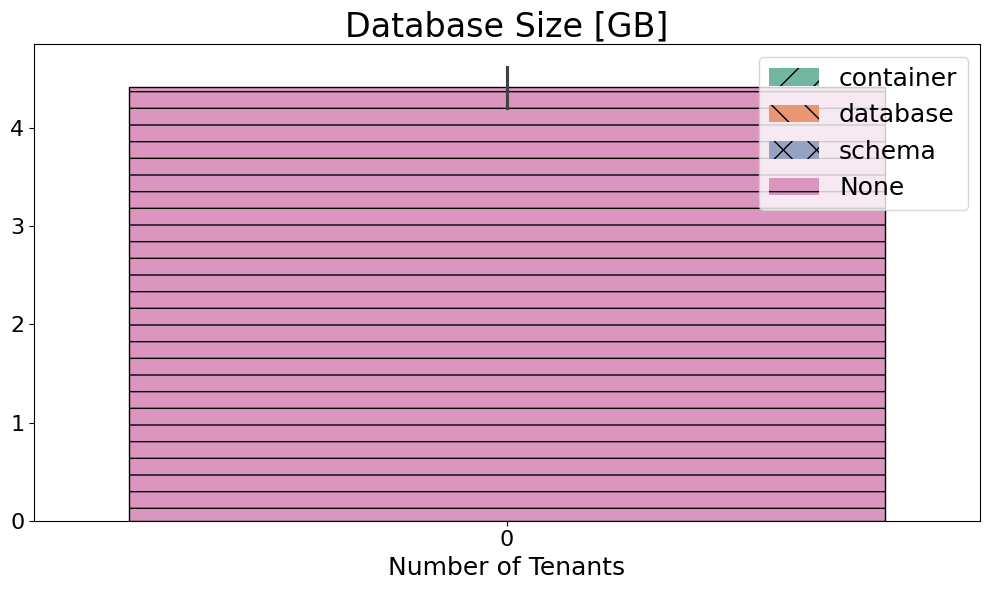

In [22]:
df_performance_first = df_performance[df_performance['client'] == 1]
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation

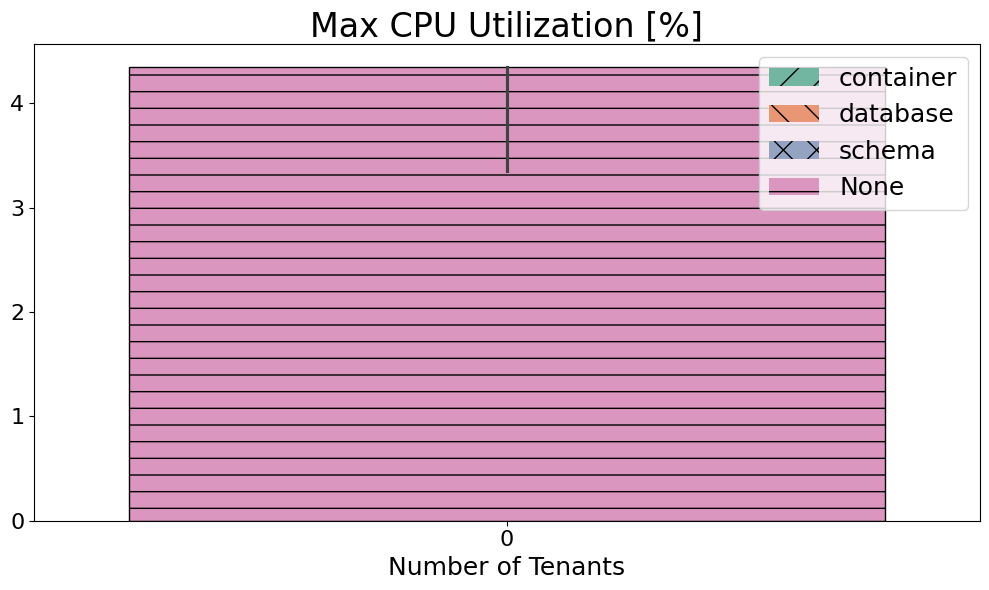

In [23]:
metric = 'total_cpu_util'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
plot_bars(df_agg, y='value', title='Max CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df_agg

## Custom Aggregation and Scale

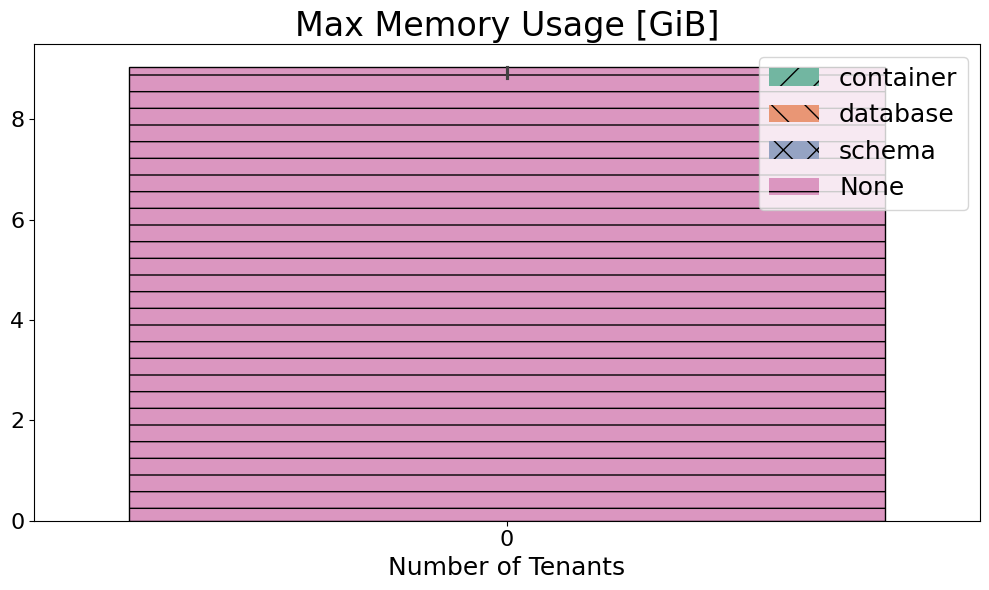

ValueError: Could not interpret value `Memory Usage [MiB]` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [24]:
metric = 'total_cpu_memory'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage [MiB]', title='Average Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

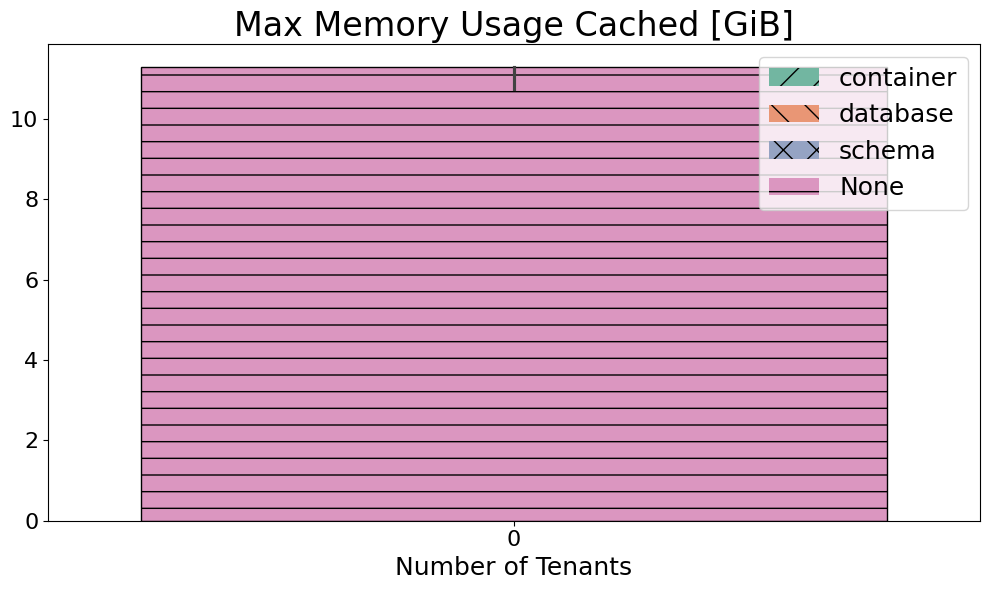

ValueError: Could not interpret value `Memory Usage Cached [MiB]` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [25]:
metric = 'total_cpu_memory_cached'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage Cached [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Average Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Loading Phase

In [26]:
df_performance = collect.get_monitoring_all("loading")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance_first

,experiment_run,client,Memory Usage [MiB],Memory Usage Cached [MiB],CPU Utilization,CPU Throttle,CPU Throttled Time [s],CPU Utilization Time [s],CPU User Time [s],CPU System Time [s],...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],type,num_tenants,vol_tenants,code
0,1,1,6990.53,7970.74,1.03,0.00,0,648.51,581.21,67.30,...,0.00,94.77,1.48,0.23,3.67,16.00,None,0,False,1776068373


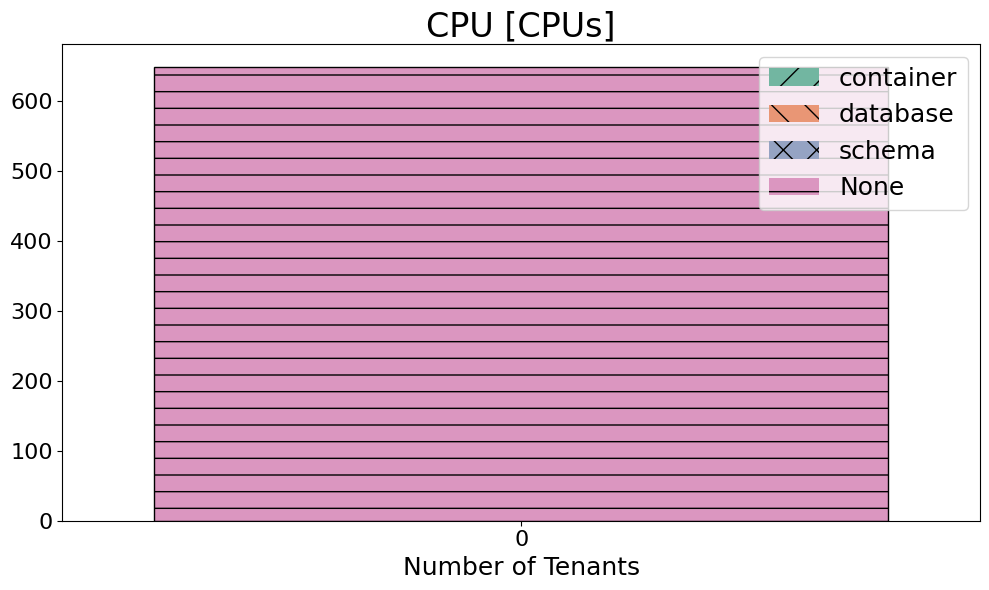

In [27]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

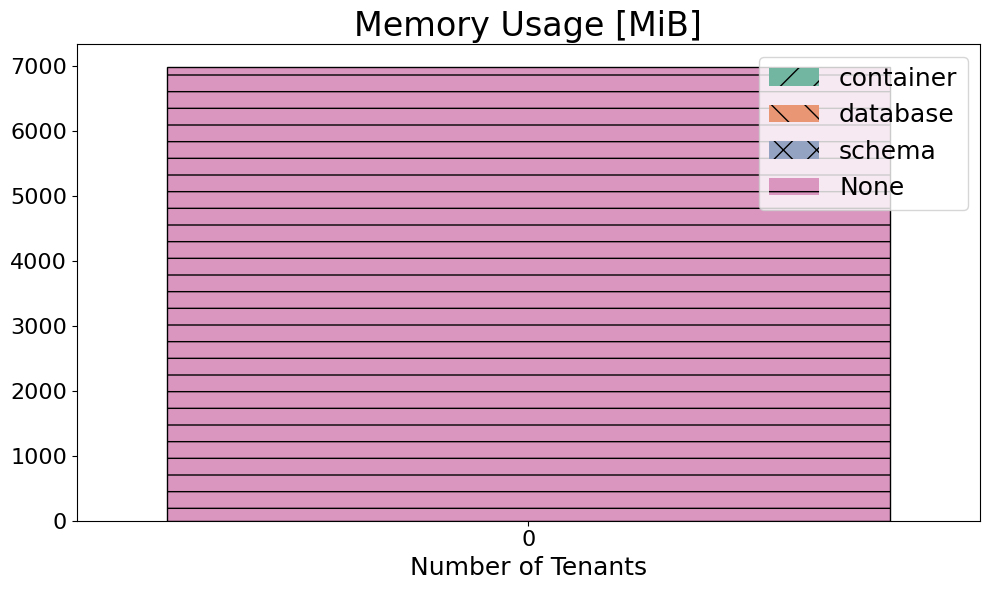

In [28]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

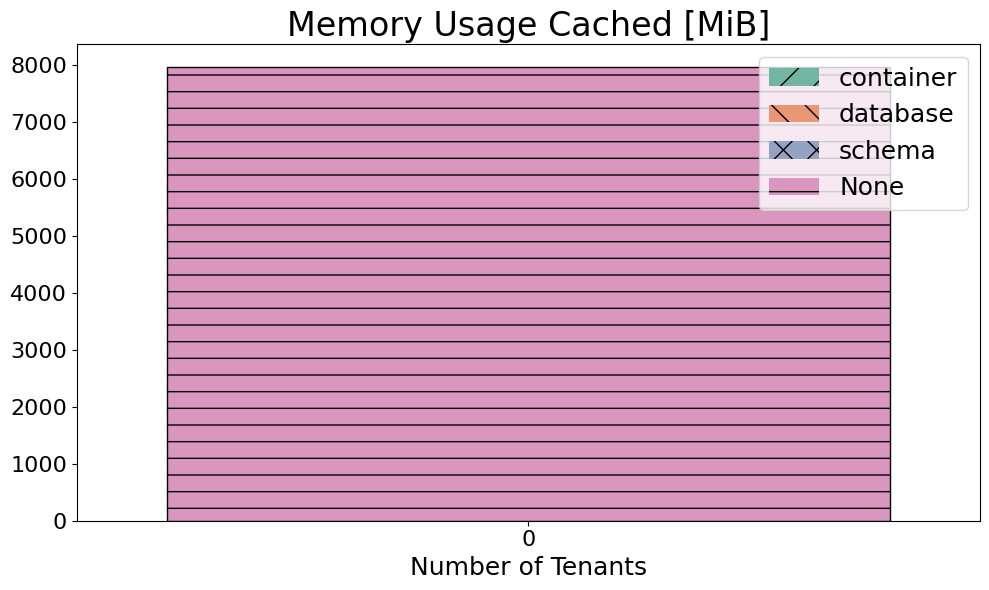

In [29]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Efficiency

In [30]:
client = 1

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

,connection,configuration,experiment_run_x,client,code,pod,pod_count,duration,bench,profile,...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1776068373,kbln7.dbmsbenchmarker,1,307,tpcc,postgres,...,inf,165.00,2.58,0.05,0.76,16.00,False,450.09,0.07,0.06
1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1776068373,kbln7.dbmsbenchmarker,1,307,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,133.56,0.04,0.06
2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1776068373,f4nnm.dbmsbenchmarker,1,305,tpcc,postgres,...,inf,165.00,2.58,0.05,0.76,16.00,False,400.23,0.06,0.05
3,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1776068373,f4nnm.dbmsbenchmarker,1,305,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,118.77,0.04,0.06


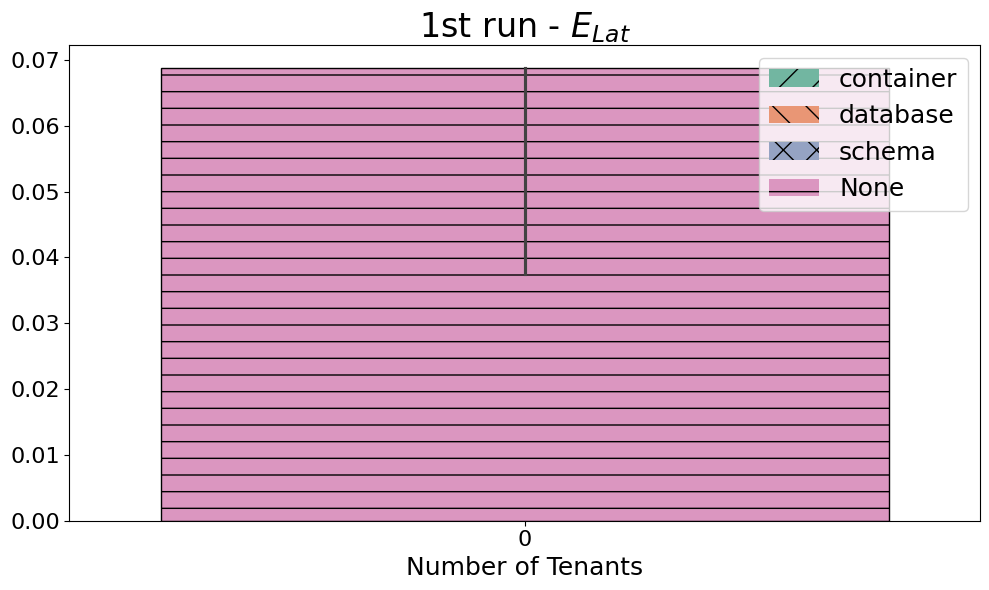

In [31]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [32]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

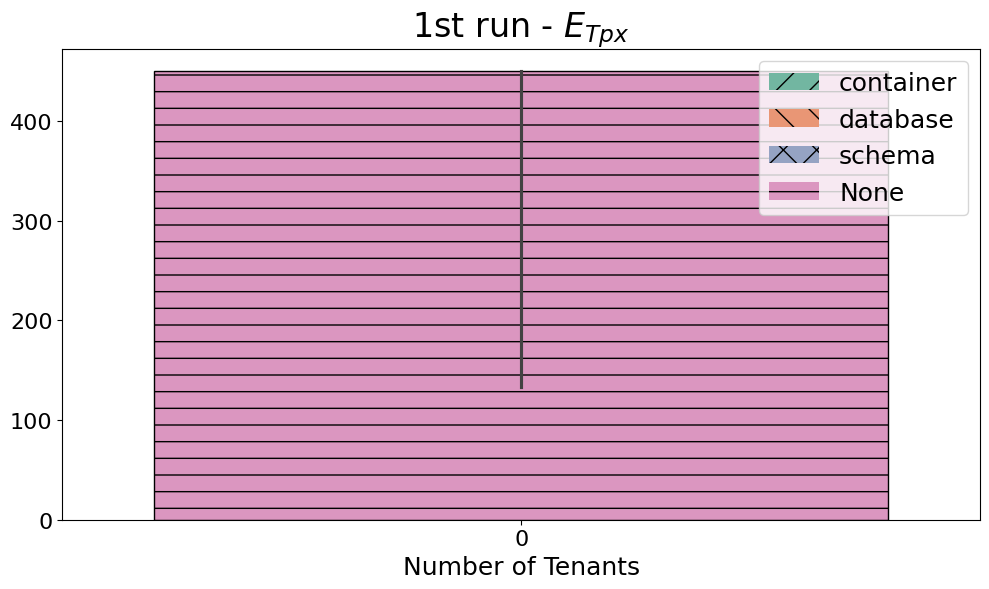

In [33]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

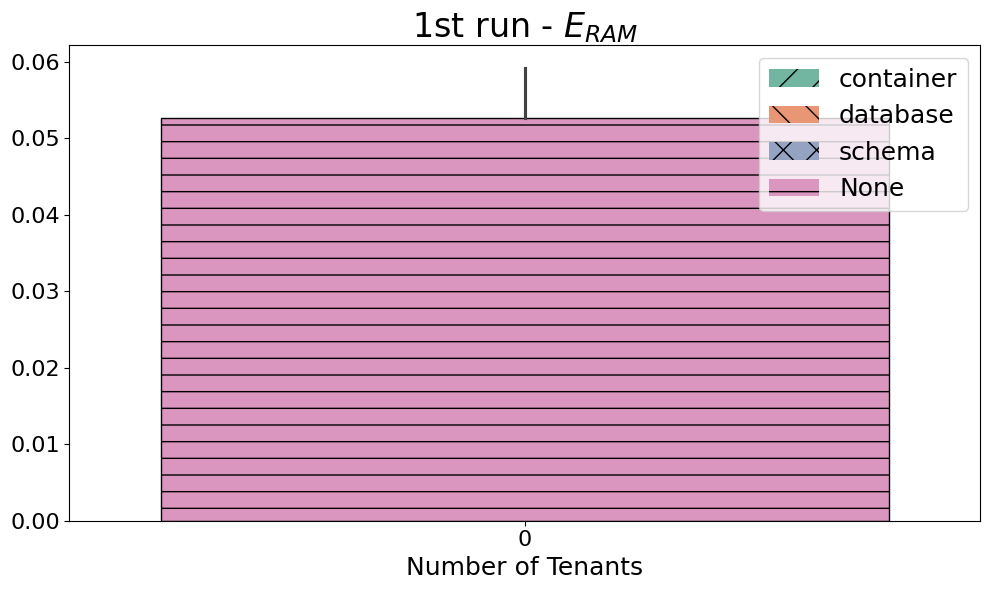

In [34]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [35]:
client = 2

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['CPUs/Request'] = merged_df['CPU [CPUs]'] / merged_df['Goodput (requests/second)'] / 600.
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']

merged_df

,connection,configuration,experiment_run_x,client,code,pod,pod_count,duration,bench,profile,...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1776068373,59c99.dbmsbenchmarker9g88r.dbmsbenchmarker,2,306,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,487.64,0.07,0.07
1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1776068373,59c99.dbmsbenchmarker9g88r.dbmsbenchmarker,2,306,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,448.15,0.07,0.07
2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1776068373,5srx2.dbmsbenchmarkernrb8j.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,446.21,0.07,0.06
3,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1776068373,5srx2.dbmsbenchmarkernrb8j.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,165.00,2.58,0.00,0.00,16.00,False,410.08,0.07,0.07


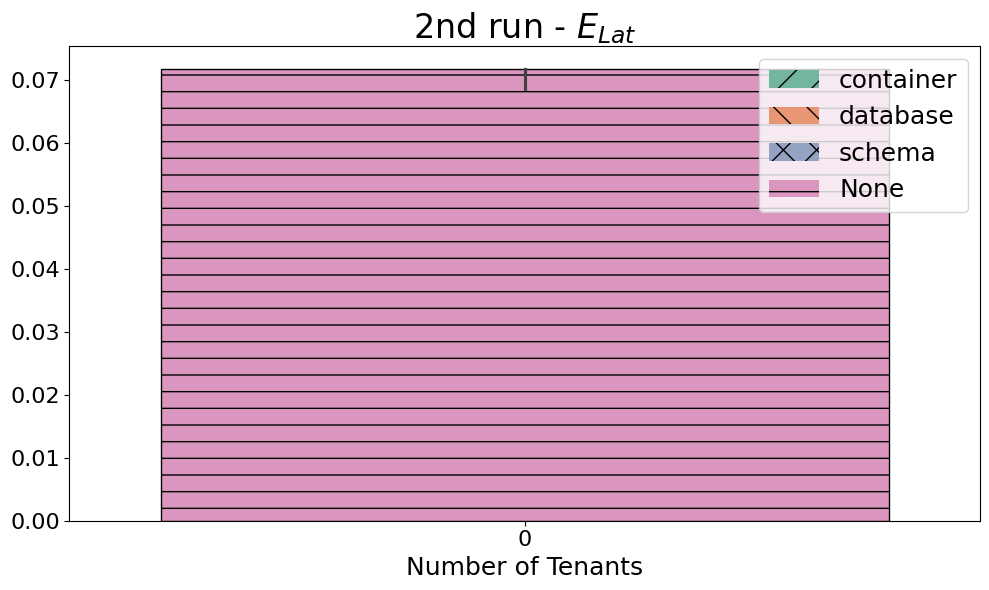

In [36]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

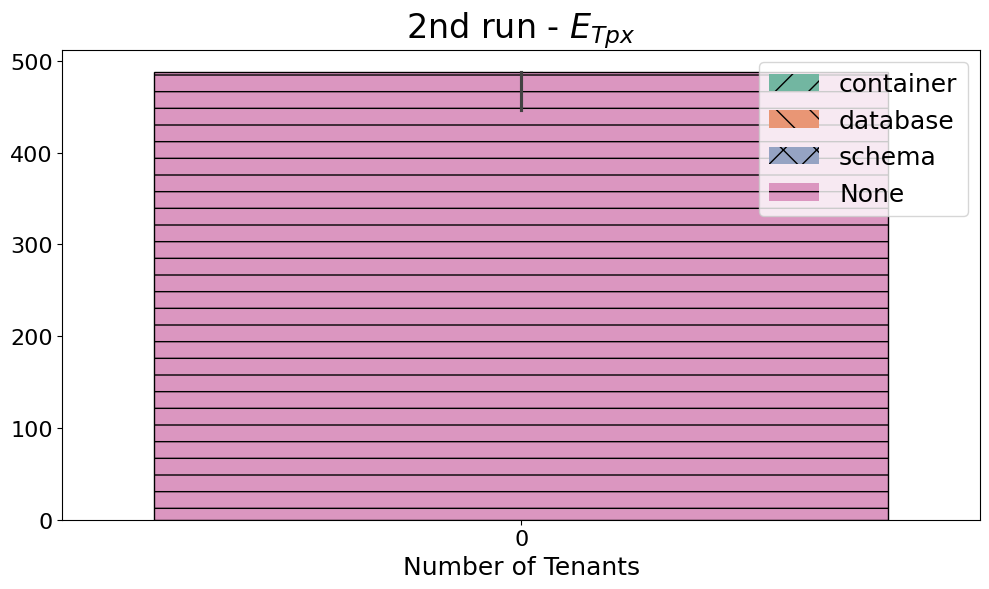

In [37]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

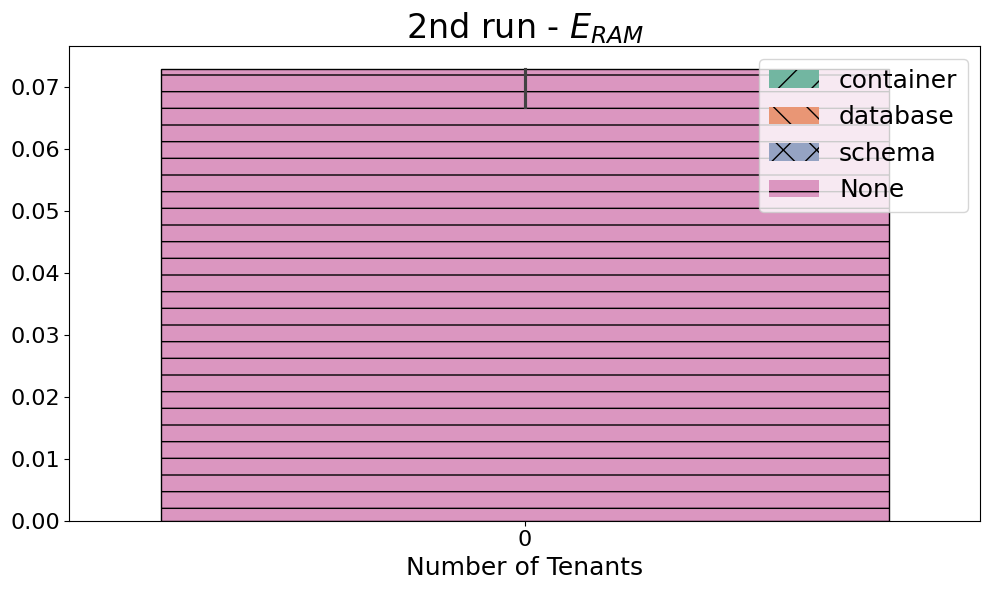

In [38]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
#zip_all_results()